In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# Exploratory Analysis

In [2]:
weather_data = pd.read_csv('data/london_weather.csv').drop(columns=['date'])
weather_data.head()

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
0,2.0,7.0,52.0,2.3,-4.1,-7.5,0.4,101900.0,9.0
1,6.0,1.7,27.0,1.6,-2.6,-7.5,0.0,102530.0,8.0
2,5.0,0.0,13.0,1.3,-2.8,-7.2,0.0,102050.0,4.0
3,8.0,0.0,13.0,-0.3,-2.6,-6.5,0.0,100840.0,2.0
4,6.0,2.0,29.0,5.6,-0.8,-1.4,0.0,102250.0,1.0


In [3]:
weather_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 15341 entries, 0 to 15340
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   cloud_cover       15322 non-null  float64
 1   sunshine          15341 non-null  float64
 2   global_radiation  15322 non-null  float64
 3   max_temp          15335 non-null  float64
 4   mean_temp         15305 non-null  float64
 5   min_temp          15339 non-null  float64
 6   precipitation     15335 non-null  float64
 7   pressure          15337 non-null  float64
 8   snow_depth        13900 non-null  float64
dtypes: float64(9)
memory usage: 1.1 MB


In [4]:
weather_data.shape

(15341, 9)

In [5]:
weather_data.describe()

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,precipitation,pressure,snow_depth
count,15322.000000,15341.000000,15322.000000,15335.000000,15305.000000,15339.000000,15335.000000,15337.000000,13900.000000
mean,5.268242,4.350238,118.756951,15.388777,11.475511,7.559867,1.668634,101536.605594,0.037986
std,2.070072,4.028339,88.898272,6.554754,5.729709,5.326756,3.738540,1049.722604,0.545633
min,0.000000,0.000000,8.000000,-6.200000,-7.600000,-11.800000,0.000000,95960.000000,0.000000
25%,4.000000,0.500000,41.000000,10.500000,7.000000,3.500000,0.000000,100920.000000,0.000000
50%,6.000000,3.500000,95.000000,15.000000,11.400000,7.800000,0.000000,101620.000000,0.000000
75%,7.000000,7.200000,186.000000,20.300000,16.000000,11.800000,1.600000,102240.000000,0.000000
max,9.000000,16.000000,402.000000,37.900000,29.000000,22.300000,61.800000,104820.000000,22.000000


In [6]:
weather_data.isnull().sum()

cloud_cover           19
sunshine               0
global_radiation      19
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64

# Handling Missing values

In [7]:
# fill cloud_cover NAs with median
median_cloud_cover = weather_data['cloud_cover'].median()
weather_data['cloud_cover'] = weather_data['cloud_cover'].fillna(median_cloud_cover)

# fill global_radiation NAs with median
median_global_radiation = weather_data['global_radiation'].median()
weather_data['global_radiation'] = weather_data['global_radiation'].fillna(median_global_radiation)

weather_data.isnull().sum()

cloud_cover            0
sunshine               0
global_radiation       0
max_temp               6
mean_temp             36
min_temp               2
precipitation          6
pressure               4
snow_depth          1441
dtype: int64

In [8]:
# drop NA values
weather_data = weather_data.dropna()

# Baseline

In [9]:
# split raw data
X = weather_data.drop(columns=['precipitation'])
y = weather_data['precipitation']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
# train model
reg = LinearRegression().fit(X_train, y_train)

In [11]:
# test model
y_pred = reg.predict(X_test)
score = r2_score(y_test, y_pred)
print(score)

0.1757439053917912


# Data Preparation

### 1. Transformation

In [12]:
# Attempt 1: standarization

# get means and standard deviations
train_mean = X_train.mean()
train_std = X_train.std()

# apply transformation
X_train_std = (X_train - train_mean) / train_std
X_test_std = (X_test - train_mean) / train_std

# train model
reg_std = LinearRegression().fit(X_train_std, y_train)

# test model
y_pred_std = reg_std.predict(X_test_std)
score_std = r2_score(y_test, y_pred_std)
print('Standarization:', score_std)

Standarization: 0.1757439053917914


In [13]:
# Attempt 2: normalization

# get mins and maxs
train_min = X_train.min()
train_max = X_train.max()

# apply transformation
X_train_norm = (X_train - train_min) / (train_max - train_min)
X_test_norm = (X_test - train_min) / (train_max - train_min)

# train model
reg_norm = LinearRegression().fit(X_train_norm, y_train)

# test model
y_pred_norm = reg_norm.predict(X_test_norm)
score_norm = r2_score(y_test, y_pred_norm)
print('Normalization:', score_norm)

Normalization: 0.1757439053917914


In [14]:
# Attempt 3: Scaling

# get max absolute value
train_max_abs = X_train.abs().max()

# apply transformation
X_train_sc = X_train / train_max_abs
X_test_sc = X_test / train_max_abs

# train model
reg_sc = LinearRegression().fit(X_train_sc, y_train)

# test model
y_pred_sc = reg_sc.predict(X_test_sc)
score_sc = r2_score(y_test, y_pred_sc)
print('Scaling:', score_sc)

Scaling: 0.1757439053917913


In [15]:
# Standarization and normalization delivered the best results. Since they scored the same, we choose either
X_train = X_train_std
X_test = X_test_std

### 2. Feature Selection

In [16]:
# Get correlation matrix
corr_matrix = X_train.corr(method='pearson')
corr_matrix.abs()

,cloud_cover,sunshine,global_radiation,max_temp,mean_temp,min_temp,pressure,snow_depth
cloud_cover,1.000000,0.734433,0.466432,0.189996,0.092644,0.062975,0.231398,0.002952
sunshine,0.734433,1.000000,0.849989,0.470128,0.401126,0.226872,0.215188,0.036352
global_radiation,0.466432,0.849989,1.000000,0.686059,0.635361,0.480452,0.145087,0.063295
max_temp,0.189996,0.470128,0.686059,1.000000,0.907476,0.806774,0.100448,0.131110
mean_temp,0.092644,0.401126,0.635361,0.907476,1.000000,0.955848,0.005458,0.156750
min_temp,0.062975,0.226872,0.480452,0.806774,0.955848,1.000000,0.069718,0.160783
pressure,0.231398,0.215188,0.145087,0.100448,0.005458,0.069718,1.000000,0.026512
snow_depth,0.002952,0.036352,0.063295,0.131110,0.156750,0.160783,0.026512,1.000000


In [17]:
# get the number of correlations above 0.80 for each variable
corr_counts = (corr_matrix > 0.80).sum(axis=1) - 1

corr_count_table = corr_counts.reset_index()
corr_count_table.columns = ['variable', 'correlations_above_0.80']

corr_count_table

,variable,correlations_above_0.80
0,cloud_cover,0
1,sunshine,1
2,global_radiation,1
3,max_temp,2
4,mean_temp,2
5,min_temp,2
6,pressure,0
7,snow_depth,0


In [18]:
# Attempt 1: drop min_temp and max_temp

# apply feature selection
X_train_f1 = X_train.drop(columns=['max_temp', 'min_temp'])
X_test_f1 = X_test.drop(columns=['max_temp', 'min_temp'])

# train model
reg_f1 = LinearRegression().fit(X_train_f1, y_train)

# test model
y_pred_f1 = reg_f1.predict(X_test_f1)
score_f1 = r2_score(y_test, y_pred_f1)
print('Drop mean_temp:', score_f1)

Drop mean_temp: 0.170823650960088


In [19]:
# Attempt 2: drop global_radiation

# apply feature selection
X_train_f2 = X_train.drop(columns=['global_radiation'])
X_test_f2 = X_test.drop(columns=['global_radiation'])

# train model
reg_f2 = LinearRegression().fit(X_train_f2, y_train)
# test model
y_pred_f2 = reg_f2.predict(X_test_f2)
score_f2 = r2_score(y_test, y_pred_f2)
print('Drop global_radiation:', score_f2)

Drop global_radiation: 0.17547942197151678


In [20]:
# Attempt 3: drop sunshine

# apply feature selection
X_train_f3 = X_train.drop(columns=['sunshine'])
X_test_f3 = X_test.drop(columns=['sunshine'])

# train model
reg_f3 = LinearRegression().fit(X_train_f3, y_train)

# test model
y_pred_f3 = reg_f3.predict(X_test_f3)
score_f3 = r2_score(y_test, y_pred_f3)
print('Drop sunshine:', score_f3)

Drop sunshine: 0.17501948524727184


Dropping the columns decreased the scores. So we don't drop anything

### 3. Outlier Detection

In [21]:
# Dataset is standardized, so it is z-score ready

# Attempt 1: threshold = 3 and m = 1

# get z-scores and outliers
z_scores_1 = X_train.abs()
outliers_1 = (z_scores_1 > 3).sum(axis=1)

# keep rows with outliers < 1
X_train_o1 = X_train[outliers_1 < 1]
y_train_o1 = y_train[outliers_1 < 1]

# train model
reg_o1 = LinearRegression().fit(X_train_o1, y_train_o1)

# test model
y_pred_o1 = reg_o1.predict(X_test)
score_o1 = r2_score(y_test, y_pred_o1)
print('Outlier attempt 1:', score_o1)

Outlier attempt 1: 0.1664080995480559


In [22]:
# Attempt 2: threshold = 3 and m = 2

# get z-scores and outliers
z_scores_2 = X_train.abs()
outliers_2 = (z_scores_2 > 3).sum(axis=1)

# keep rows with outliers < 2
X_train_o2 = X_train[outliers_2 < 2]
y_train_o2 = y_train[outliers_2 < 2]

# train model
reg_o2 = LinearRegression().fit(X_train_o2, y_train_o2)

# test model
y_pred_o2 = reg_o2.predict(X_test)
score_o2 = r2_score(y_test, y_pred_o2)
print('Outlier attempt 2:', score_o2)

Outlier attempt 2: 0.17573265356025103


In [23]:
# Attempt 3: threshold = 4 and m = 2

# get z-scores and outliers
z_scores_3 = X_train.abs()
outliers_3 = (z_scores_3 > 4).sum(axis=1)

# keep rows with outliers < 2
X_train_o3 = X_train[outliers_3 < 2]
y_train_o3 = y_train[outliers_3 < 2]

# train model
reg_o3 = LinearRegression().fit(X_train_o3, y_train_o3)

# test model
y_pred_o3 = reg_o3.predict(X_test)
score_o3 = r2_score(y_test, y_pred_o3)
print('Outlier attempt 3:', score_o3)

Outlier attempt 3: 0.1757439053917914


# Plots

### 1. Transformation plots

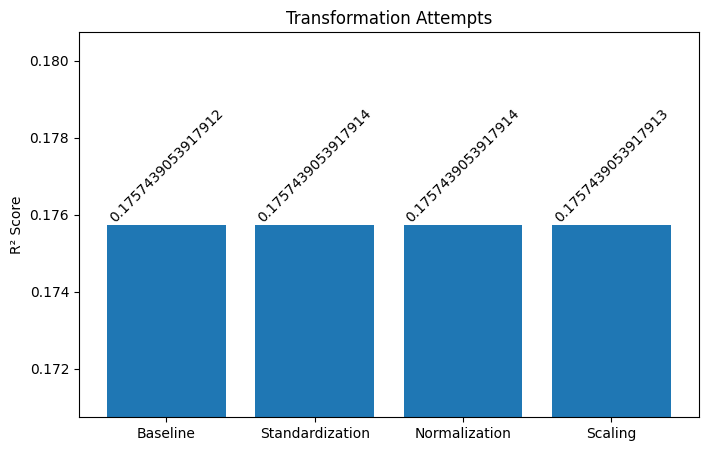

In [24]:
transformation_labels = ['Baseline', 'Standardization', 'Normalization', 'Scaling']
transformation_scores = [score, score_std, score_norm, score_sc]

plt.figure(figsize=(8, 5))
plt.bar(transformation_labels, transformation_scores)
plt.ylabel('R² Score')
plt.title('Transformation Attempts')
plt.ylim(min(transformation_scores) - 0.005, max(transformation_scores) + 0.005)

for i, score in enumerate(transformation_scores):
    plt.text(i, score, f'{score:.16f}', ha='center', va='bottom', rotation=45)

plt.show()

# 2. Feature Selection

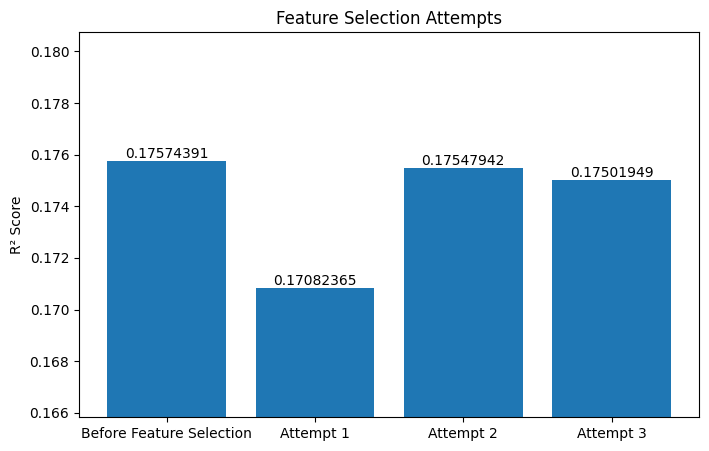

In [25]:
feature_labels = ['Before Feature Selection', 'Attempt 1', 'Attempt 2', 'Attempt 3']
feature_scores = [score_std, score_f1, score_f2, score_f3]

plt.figure(figsize=(8, 5))
plt.bar(feature_labels, feature_scores)
plt.ylabel('R² Score')
plt.title('Feature Selection Attempts')
plt.ylim(min(feature_scores) - 0.005, max(feature_scores) + 0.005)

for i, score in enumerate(feature_scores):
    plt.text(i, score, f'{score:.8f}', ha='center', va='bottom')

plt.show()

# 3. Outlier Detection Plots

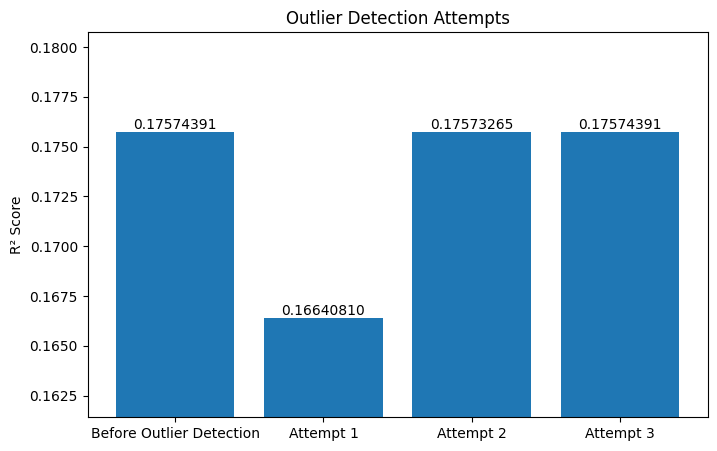

In [26]:
outlier_labels = ['Before Outlier Detection', 'Attempt 1', 'Attempt 2', 'Attempt 3']
outlier_scores = [score_std, score_o1, score_o2, score_o3]

plt.figure(figsize=(8, 5))
plt.bar(outlier_labels, outlier_scores)
plt.ylabel('R² Score')
plt.title('Outlier Detection Attempts')
plt.ylim(min(outlier_scores) - 0.005, max(outlier_scores) + 0.005)

for i, score in enumerate(outlier_scores):
    plt.text(i, score, f'{score:.8f}', ha='center', va='bottom')

plt.show()

# Final Model Summary

- **Best transformation:** Standardization
- **Best feature-selection step:** Drop None
- **Best outlier-detection setting:** No outlier detection
- **Final test R²:** 0.1757439053917914